# without spliting attack

# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Imports

In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 937.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 91.6 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.15.1
    Uninstalling h5py-3.15.1:
      Successfully uninstalled h5py-3.15.1
  Attempting uninstall: keras
    Found existing installation: keras 3.10.0
    Uninstalling keras-3.10.0:
      Successfully uninstalled keras-3.10.0


In [ ]:
import numpy as np
import os
import json
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


# Paths

In [ ]:
BASE_PATH = "/content/drive/MyDrive/DepiProject"
DATA_PATH = os.path.join(BASE_PATH, "swat_preprocessed")
MODEL_PATH = os.path.join(BASE_PATH, "models")

os.makedirs(MODEL_PATH, exist_ok=True)

# Load Windowed Data

In [ ]:
X_train = np.load(os.path.join(DATA_PATH, "X_train.npy"))
y_train = np.load(os.path.join(DATA_PATH, "y_train.npy"))

X_val = np.load(os.path.join(DATA_PATH, "X_val.npy"))
y_val = np.load(os.path.join(DATA_PATH, "y_val.npy"))

X_attack = np.load(os.path.join(DATA_PATH, "X_attack.npy"))
y_attack = np.load(os.path.join(DATA_PATH, "y_attack.npy"))

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Attack:", X_attack.shape)

Train: (86181, 15, 46)
Val: (9574, 15, 46)
Attack: (89998, 15, 46)


# Sanity Check (CRITICAL)

In [ ]:
print("Train anomaly %:", y_train.mean())
print("Val anomaly %:", y_val.mean())
print("Attack anomaly %:", y_attack.mean())

Train anomaly %: 0.0
Val anomaly %: 0.0
Attack anomaly %: 0.1225027222827174


# Build Autoencoder

## flatten windows → Dense AE (fast + stable)

In [ ]:
window_size = X_train.shape[1]
n_features = X_train.shape[2]

input_dim = window_size * n_features

X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat   = X_val.reshape(len(X_val), -1)
X_attack_flat = X_attack.reshape(len(X_attack), -1)

## Model Architecture

In [ ]:
def build_autoencoder(input_dim):

    inputs = keras.Input(shape=(input_dim,))

    x = layers.Dense(256, activation="relu")(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(256, activation="relu")(x)

    outputs = layers.Dense(input_dim, activation="linear")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse"
    )

    return model

## Train Model

In [ ]:
autoencoder = build_autoencoder(input_dim)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train_flat,
    X_train_flat,
    validation_data=(X_val_flat, X_val_flat),
    epochs=20,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.1446 - val_loss: 0.0897
Epoch 2/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0780 - val_loss: 0.0693
Epoch 3/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0608 - val_loss: 0.0692
Epoch 4/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0569 - val_loss: 0.0607
Epoch 5/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0527 - val_loss: 0.0573
Epoch 6/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0484 - val_loss: 0.0530
Epoch 7/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0460 - val_loss: 0.0539
Epoch 8/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0505 - val_loss: 0.0527
Epoch 9/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0391 - val_loss: 0.0571
Epoch 10/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0420 - val_loss: 0.0455
Epoch 11/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0375 - val_loss: 0.0426
Epoch 12/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/st

## Plot Training Curve

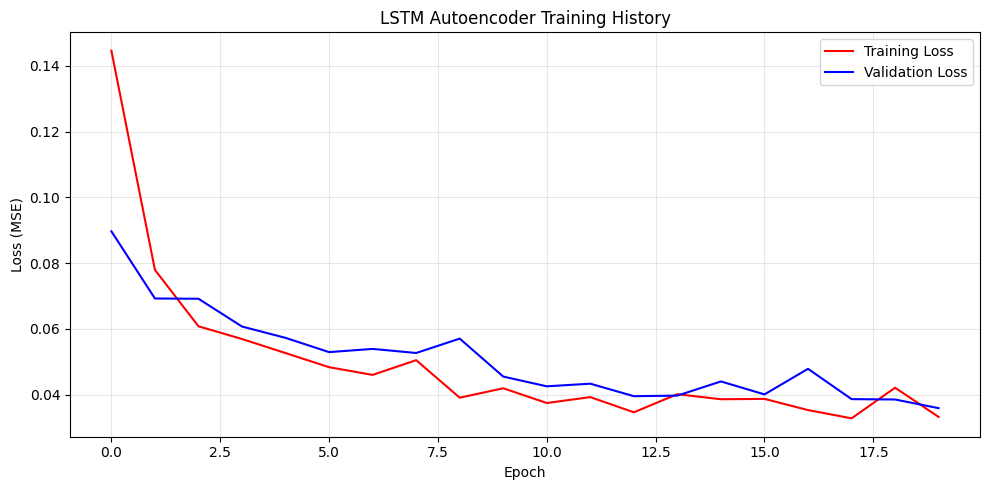

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(history.history['loss'], label='Training Loss', color='r')
ax.plot(history.history['val_loss'], label='Validation Loss', color='b')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title('LSTM Autoencoder Training History')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Compute Reconstruction Errors

In [ ]:
def reconstruction_errors(model, X):
    preds = model.predict(X)
    errors = np.mean(np.square(X - preds), axis=1)
    return errors

val_errors = reconstruction_errors(autoencoder, X_val_flat)
attack_errors = reconstruction_errors(autoencoder, X_attack_flat)

300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 2s 883us/step


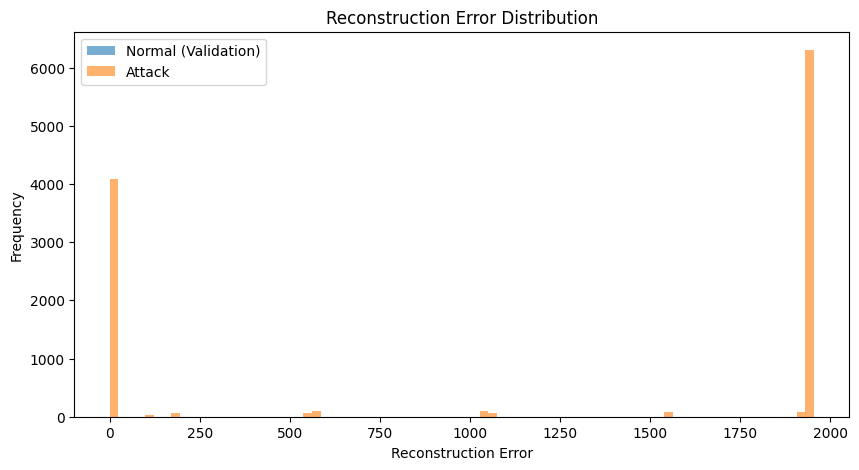

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(val_errors, bins=80, alpha=0.6, label="Normal (Validation)")
plt.hist(attack_errors[y_attack == 1], bins=80, alpha=0.6, label="Attack")

plt.legend()
plt.title("Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve

y_attack_aligned = y_attack[:]

precision, recall, thresholds = precision_recall_curve(
    y_attack_aligned,
     attack_errors
)

# # Choose threshold that maximizes F1
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1:", f1_scores[best_idx])

Best Threshold: 17.139162
Precision: 0.9899090392268334
Recall: 0.6317460317460317
F1: 0.7712751184375232


In [ ]:
threshold = np.percentile(val_errors, 99)

print("Chosen threshold:", threshold)

Chosen threshold: 0.16481021


In [ ]:
y_pred_attack = (attack_errors > best_threshold).astype(int)


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_attack, y_pred_attack)

print(cm)

[[78902    71]
 [ 4061  6964]]


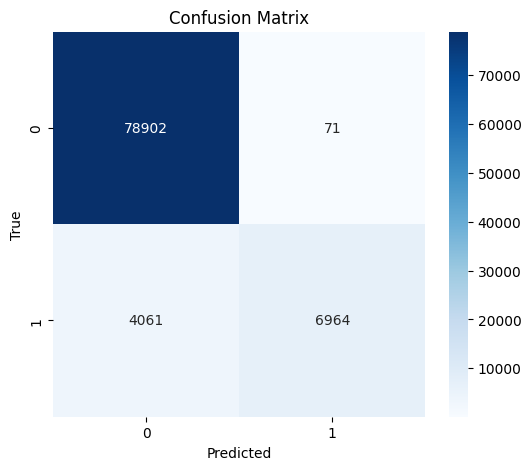

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_attack, y_pred_attack))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97     78973
           1       0.99      0.63      0.77     11025

    accuracy                           0.95     89998
   macro avg       0.97      0.82      0.87     89998
weighted avg       0.96      0.95      0.95     89998



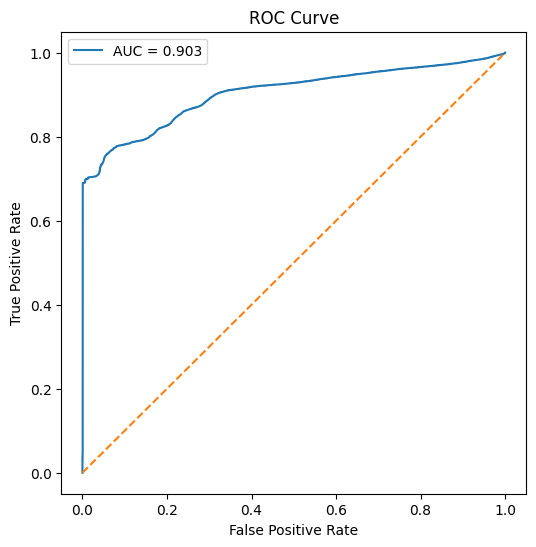

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_attack, attack_errors)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

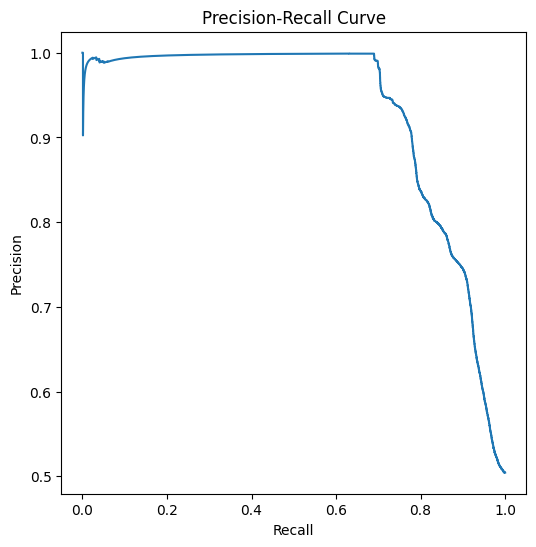

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_attack, attack_errors)

plt.figure(figsize=(6,6))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_attack, y_pred_attack))
print("Precision:", precision_score(y_attack, y_pred_attack))
print("Recall:", recall_score(y_attack, y_pred_attack))
print("F1 Score:", f1_score(y_attack, y_pred_attack))

Accuracy: 0.9540878686193026
Precision: 0.989907604832978
Recall: 0.631655328798186
F1 Score: 0.7712070874861573
